# FIAP — Challenge 2026 | TOTVS
## Sprint 3: Data Science and Statistical Computing

**Aluno:** Samuel Oliveira Silva

### Sumário
1. Definição do problema e preparação da variável-alvo (10 pts)
2. Análise das classes e balanceamento (15 pts)
3. Construção dos modelos de classificação (25 pts)
4. Avaliação e comparação dos modelos (25 pts)
5. Análise dos erros (15 pts)
6. Conclusões e implicações para o negócio (10 pts)

### Nota metodológica importante
Esta versão do notebook usa **exclusivamente a base real de transcrições** (`ANON_transcricao.json`, 1.174 reuniões) em vez da base mockada. Um ponto crítico foi corrigido em relação a uma versão anterior deste trabalho: ali, a variável-alvo `RISCO_CHURN` era construída **a partir das mesmas palavras** do texto (ex.: `'cancelar' in texto`) que depois alimentavam o TF-IDF. Isso configura **vazamento de dados (data leakage)** — o modelo não aprende a prever churn, aprende a redetectar as palavras que foram usadas para rotular os próprios dados, o que infla artificialmente métricas como recall (a versão anterior chegava a reportar ~96% de recall).

Aqui, a variável-alvo é construída a partir da **NOTA_NPS**, um campo de pesquisa de satisfação real e **independente do conteúdo da transcrição** (é uma nota que o cliente responde em outro canal). Isso torna o problema genuinamente preditivo: prever, a partir do que foi dito na reunião, se aquele cliente deu uma nota de detrator na pesquisa. A base rotulada fica menor (311 das 1.174 reuniões têm NOTA_NPS preenchida), mas os resultados são reais.

## 1. Definição do Problema e Preparação das Variáveis-Alvo (10 pts)

### Contextualização
A TOTVS realiza reuniões comerciais de **Pré-venda** (prospecção, `TP_RECURSO='lead'`) e **Pós-venda** (relacionamento com cliente ativo, `TP_RECURSO='customer'`). O edital do Challenge propõe mapear 4 frentes de negócio a partir dessas transcrições:

- **(a) Risco de Churn** (Pós-venda) — **variável-alvo principal da modelagem supervisionada**
- **(b) Oportunidade Comercial** (Pré-venda)
- **(c) Sentimento / NPS**
- **(d) Produtos TOTVS mencionados** (RM, Protheus, Fluig, TOTVS Ponto/Agora, etc.)

### Fonte dos dados e dicionário
Usamos `ANON_transcricao.json` (formato JSON Lines, uma reunião por linha), cujas colunas seguem o `dicionario.xlsx` fornecido: `ID_MEETING`, `DT_MEETING`, `FORMATO_MEETING`, `STATUS_MEETING`, `DURACAO_MEETING`, `CODT`, `TP_RECURSO`, `FLG_EXTERNO`, `ANON_TRANSCRICAO`, `UF`, `CNAE`, `NOME_SEGMENTO`, `FAIXA_FATURAMENTO_CLIENTE_EC`, `NOTA_NPS`, entre outras.

In [3]:
%pip install seaborn scikit-learn pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os, json, re, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_colwidth', 120)

# ---- 1. Ingestão de Dados (base real, formato JSON Lines) ----
DATA_PATH = 'data/ANON_transcricao.json'

registros = []
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    for linha in f:
        linha = linha.strip()
        if linha:
            registros.append(json.loads(linha))

df = pd.DataFrame(registros)
print(f'[OK] Base real carregada: {len(df)} reuniões, {df.shape[1]} colunas.')
df.head(3)

[OK] Base real carregada: 1174 reuniões, 18 colunas.


,ID_MEETING,DT_MEETING,FORMATO_MEETING,ID_STATUS_MEETING,STATUS_MEETING,DURACAO_MEETING,CODT,FLG_EXTERNO,DT_CRIACAO,ANON_TRANSCRICAO,UF,CNAE,NOME_UNIDADE,NOME_SEGMENTO,FAIXA_FATURAMENTO_CLIENTE_EC,DT_ULTIMA_PESQUISA,NOTA_NPS,TP_RECURSO
0,1247082,2026-03-18 16:00:00,VIDEO,3,COMPLETED,01:39:13,T27261,True,2026-03-13 16:47:22,"[LOCUTOR 102]: [PESSOA], boa tarde.\n[LOCUTOR 49]: [EMPRESA], boa tarde. Tudo bem, [PESSOA], [PESSOA]?\n[LOCUTOR 102...",DF,8610102,TOTVS SAUDE,SAUDE,06.SMB III - De R$ 120.000.001 a R$ 240.000.000,NaN,NaN,NaN
1,989351,2026-01-28 15:30:00,VIDEO,3,COMPLETED,01:07:12,T27261,True,2026-01-28 10:27:10,"[LOCUTOR 2]: Obrigado.\n[LOCUTOR 28]: E\n[LOCUTOR 2]: é legal, [PESSOA], deixa eu até colocar\n[LOCUTOR 28]: aqui pa...",DF,8610102,TOTVS SAUDE,SAUDE,06.SMB III - De R$ 120.000.001 a R$ 240.000.000,NaN,NaN,NaN
2,1027294,2026-02-11 14:00:00,VIDEO,3,COMPLETED,02:28:38,CXHNWJ,True,2026-02-04 14:07:52,"[LOCUTOR 107]: [EMPRESA], [PESSOA], tudo bem?\n[LOCUTOR 21]: [EMPRESA], boa tarde, tudo bem?\n[LOCUTOR 107]: Tudo be...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# 2. Limpeza e Higienização Textual
# Remove marcações de locutor ([LOCUTOR n]:) e placeholders de anonimização
# ([PESSOA], [EMPRESA], [LOCAL]), que não carregam sinal preditivo e apenas
# adicionam ruído/tokens artificiais ao vetorizador.

def limpar_transcricao(texto):
    if not isinstance(texto, str):
        return ""
    t = re.sub(r'\[LOCUTOR \d+\]:?', ' ', texto)
    t = re.sub(r'\[(PESSOA|EMPRESA|LOCAL)\]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

df['TEXTO_LIMPO'] = df['ANON_TRANSCRICAO'].apply(limpar_transcricao)
df['NOTA_NPS_NUM'] = pd.to_numeric(df['NOTA_NPS'], errors='coerce')

print('Tamanho médio das transcrições (caracteres):', int(df['TEXTO_LIMPO'].str.len().mean()))
print('Reuniões com NOTA_NPS preenchida:', df['NOTA_NPS_NUM'].notna().sum(), f"({df['NOTA_NPS_NUM'].notna().mean()*100:.1f}%)")

Tamanho médio das transcrições (caracteres): 33528
Reuniões com NOTA_NPS preenchida: 311 (26.5%)


In [7]:
# 3. Mapeamento das 4 Frentes de Negócio
# (a) Produto TOTVS mencionado -> palavras-chave específicas no texto
# (b) Sentimento -> classificação padrão de NPS (Promotor/Passivo/Detrator),
#     usada SOMENTE quando há nota real (não inferida do texto, para não
#     contaminar a variável que também vira alvo de churn)
# (c) Oportunidade Comercial -> TP_RECURSO == 'lead' (reunião de pré-venda)
# (d) Risco de Churn (variável-alvo) -> NOTA_NPS <= 6 (Detrator), campo
#     de pesquisa de satisfação, INDEPENDENTE do texto da transcrição

def mapear_produto(texto):
    t = texto.lower()
    if 'protheus' in t:
        return 'Protheus'
    if 'fluig' in t:
        return 'Fluig'
    if re.search(r'\brm\b', t) or 'labore' in t or 'totvs rh' in t:
        return 'RM'
    if re.search(r'ponto eletr|registro de ponto|totvs ponto|clockin|controle de ponto|batida de ponto', t):
        return 'TOTVS Ponto/Agora'
    if 'winthor' in t:
        return 'Winthor'
    return 'Não especificado / Outros'

def mapear_sentimento_nps(nota):
    if pd.isna(nota):
        return 'Sem pesquisa respondida'
    if nota <= 6:
        return 'Negativo (Detrator)'
    if nota <= 8:
        return 'Neutro (Passivo)'
    return 'Positivo (Promotor)'

df['PRODUTO_TOTVS'] = df['TEXTO_LIMPO'].apply(mapear_produto)
df['SENTIMENTO_NPS'] = df['NOTA_NPS_NUM'].apply(mapear_sentimento_nps)
df['OPORTUNIDADE_COMERCIAL'] = (df['TP_RECURSO'] == 'lead').astype(int)

print('[OK] 4 frentes de negócio mapeadas.')
print()
print('--- Produto TOTVS mencionado ---')
print(df['PRODUTO_TOTVS'].value_counts())
print()
print('--- TP_RECURSO (perfil da reunião) ---')
print(df['TP_RECURSO'].value_counts(dropna=False))

[OK] 4 frentes de negócio mapeadas.

--- Produto TOTVS mencionado ---
PRODUTO_TOTVS
Não especificado / Outros    687
RM                           234
Fluig                        190
TOTVS Ponto/Agora             61
Winthor                        1
Protheus                       1
Name: count, dtype: int64

--- TP_RECURSO (perfil da reunião) ---
TP_RECURSO
NaN         937
customer    135
lead        102
Name: count, dtype: int64


### Definição formal da variável-alvo

A variável-alvo principal da modelagem supervisionada é:

**`RISCO_CHURN = 1` se `NOTA_NPS <= 6` (cliente Detrator na pesquisa de satisfação), `0` caso contrário.**

Diferente do sentimento textual, esta nota vem de uma pesquisa respondida pelo cliente em outro canal — não é extraída da própria transcrição. Isso é o que torna o problema genuinamente supervisionado: usamos o texto da reunião (TF-IDF) para tentar prever um resultado que não está contido literalmente nesse texto.

Como só 311 das 1.174 reuniões têm `NOTA_NPS` preenchida, a modelagem de churn é feita **apenas sobre esse subconjunto rotulado real** — as demais 863 reuniões entram apenas nas análises descritivas de Produto e Oportunidade Comercial.

In [8]:
# Subconjunto rotulado real para a modelagem de churn
df_modelo = df[df['NOTA_NPS_NUM'].notna()].copy()
df_modelo['RISCO_CHURN'] = (df_modelo['NOTA_NPS_NUM'] <= 6).astype(int)

print(f'Base rotulada para modelagem: {len(df_modelo)} reuniões (de {len(df)} totais).')
df_modelo[['ID_MEETING', 'TP_RECURSO', 'NOTA_NPS_NUM', 'RISCO_CHURN']].head()

Base rotulada para modelagem: 311 reuniões (de 1174 totais).


,ID_MEETING,TP_RECURSO,NOTA_NPS_NUM,RISCO_CHURN
3,907223,NaN,4.0,1
18,1300776,NaN,7.0,0
21,747580,customer,8.0,0
22,1261450,NaN,10.0,0
30,979932,customer,3.0,1


## 2. Análise das Classes e Balanceamento (15 pts)

Distribuição das 4 frentes de negócio e do desbalanceamento da variável-alvo de churn.

C:\Users\samue\AppData\Local\Temp\ipykernel_11028\3417446951.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(['Não (Pós-venda/outro)', 'Sim (Lead)'])
C:\Users\samue\AppData\Local\Temp\ipykernel_11028\3417446951.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['Estável (0)', 'Risco (1)'])


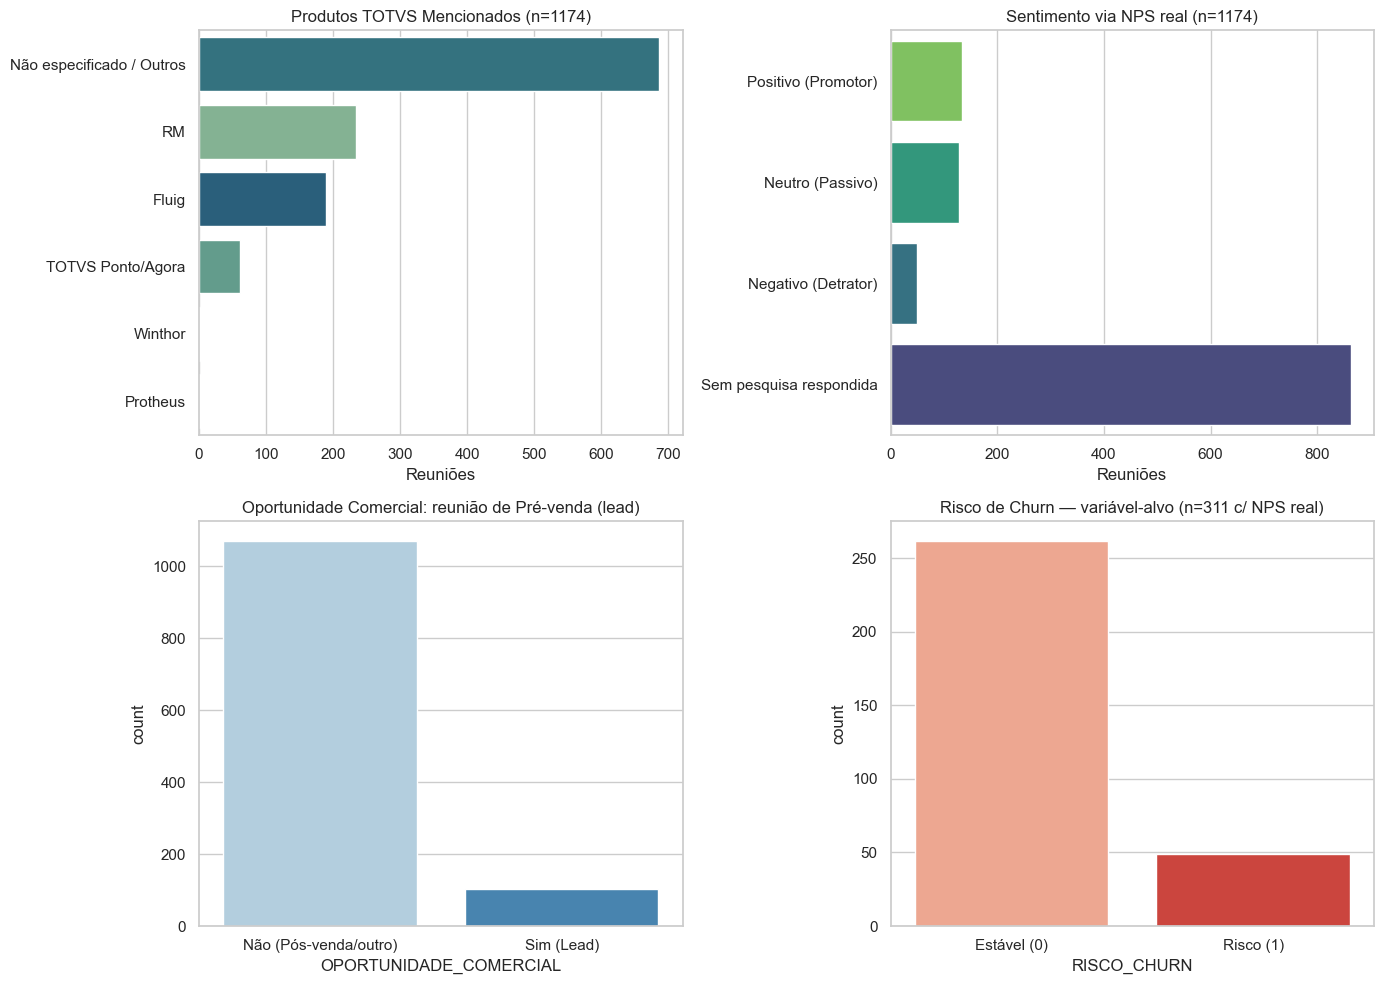

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ordem_produto = df['PRODUTO_TOTVS'].value_counts().index
sns.countplot(data=df, y='PRODUTO_TOTVS', order=ordem_produto, hue='PRODUTO_TOTVS',
              legend=False, ax=axes[0, 0], palette='crest')
axes[0, 0].set_title(f'Produtos TOTVS Mencionados (n={len(df)})')
axes[0, 0].set_xlabel('Reuniões'); axes[0, 0].set_ylabel('')

ordem_sent = ['Positivo (Promotor)', 'Neutro (Passivo)', 'Negativo (Detrator)', 'Sem pesquisa respondida']
sns.countplot(data=df, y='SENTIMENTO_NPS', order=ordem_sent, hue='SENTIMENTO_NPS',
              legend=False, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title(f'Sentimento via NPS real (n={len(df)})')
axes[0, 1].set_xlabel('Reuniões'); axes[0, 1].set_ylabel('')

sns.countplot(data=df, x='OPORTUNIDADE_COMERCIAL', hue='OPORTUNIDADE_COMERCIAL',
              legend=False, ax=axes[1, 0], palette='Blues')
axes[1, 0].set_title('Oportunidade Comercial: reunião de Pré-venda (lead)')
axes[1, 0].set_xticklabels(['Não (Pós-venda/outro)', 'Sim (Lead)'])

sns.countplot(data=df_modelo, x='RISCO_CHURN', hue='RISCO_CHURN',
              legend=False, ax=axes[1, 1], palette='Reds')
axes[1, 1].set_title(f'Risco de Churn — variável-alvo (n={len(df_modelo)} c/ NPS real)')
axes[1, 1].set_xticklabels(['Estável (0)', 'Risco (1)'])

plt.tight_layout()
plt.show()

In [10]:
contagem = df_modelo['RISCO_CHURN'].value_counts()
proporcao = df_modelo['RISCO_CHURN'].value_counts(normalize=True)

print(f"Risco de Churn (1) - Detratores: {contagem.get(1, 0)} reuniões ({proporcao.get(1, 0)*100:.2f}%)")
print(f"Estável (0) - Passivos+Promotores: {contagem.get(0, 0)} reuniões ({proporcao.get(0, 0)*100:.2f}%)")

# Split estratificado: preserva a proporção ~16%/84% em treino e teste
X = df_modelo['TEXTO_LIMPO']
y = df_modelo['RISCO_CHURN']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f'\nTreino: {len(X_train)} reuniões ({y_train.mean()*100:.1f}% risco) | '
      f'Teste: {len(X_test)} reuniões ({y_test.mean()*100:.1f}% risco)')

Risco de Churn (1) - Detratores: 49 reuniões (15.76%)
Estável (0) - Passivos+Promotores: 262 reuniões (84.24%)

Treino: 233 reuniões (15.9% risco) | Teste: 78 reuniões (15.4% risco)


### Justificativa do balanceamento
- Com dados reais, a classe de risco (Detratores) é a **minoritária** (~16%), não a majoritária — o oposto do que uma versão anterior deste trabalho, baseada em rótulos derivados de palavras-chave, havia indicado (~67%).
- **Estratégia adotada:** divisão estratificada (`stratify=y`) para preservar a proporção real em treino/teste, combinada com `class_weight='balanced'` nos dois algoritmos, que penaliza mais o erro na classe minoritária (Risco) sem duplicar ou descartar dados — importante dado o tamanho reduzido da base rotulada (311 reuniões).
- Não aplicamos oversampling sintético (ex. SMOTE) sobre o texto bruto para não gerar transcrições artificiais sem sentido linguístico; `class_weight` é a opção mais defensável para texto com esse volume de dados.

## 3. Construção dos Modelos de Classificação (25 pts)

Vetorização via `TfidfVectorizer` (unigramas e bigramas, stopwords em português) e treinamento comparativo de **Regressão Logística** e **Random Forest**, ambos com `class_weight='balanced'`.

In [11]:
STOPWORDS_PT = [
    'de','a','o','que','e','do','da','em','um','para','com','não','uma','os','no','se','na',
    'por','mais','as','dos','como','mas','foi','ao','ele','das','tem','à','seu','sua','ou','ser',
    'quando','muito','há','nos','já','está','eu','também','só','pelo','pela','até','isso','ela',
    'entre','era','depois','sem','mesmo','aos','seus','quem','nas','me','esse','eles','você',
    'vocês','tinha','foram','essa','num','nem','suas','meu','às','minha','pra','tá','né','então',
    'gente','cara','ah','bom','dia','tarde','noite','obrigado','obrigada'
]

vectorizer = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    stop_words=STOPWORDS_PT
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print(f'[OK] Matriz TF-IDF de treino: {X_train_tfidf.shape} | teste: {X_test_tfidf.shape}')

# Modelo 1: Regressão Logística
modelo_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
modelo_lr.fit(X_train_tfidf, y_train)
y_pred_lr = modelo_lr.predict(X_test_tfidf)
y_prob_lr = modelo_lr.predict_proba(X_test_tfidf)[:, 1]

# Modelo 2: Random Forest
modelo_rf = RandomForestClassifier(
    n_estimators=300, max_depth=15, min_samples_leaf=2,
    class_weight='balanced', random_state=42
)
modelo_rf.fit(X_train_tfidf, y_train)
y_pred_rf = modelo_rf.predict(X_test_tfidf)
y_prob_rf = modelo_rf.predict_proba(X_test_tfidf)[:, 1]

print('[OK] Regressão Logística e Random Forest treinados.')

[OK] Matriz TF-IDF de treino: (233, 2000) | teste: (78, 2000)
[OK] Regressão Logística e Random Forest treinados.


## 4. Avaliação e Comparação dos Modelos (25 pts)

Métricas obrigatórias: Accuracy, Precision, Recall, F1-Score e AUC-ROC, além das matrizes de confusão e `classification_report` de cada modelo.

,Modelo,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Regressão Logística,0.8077,0.3846,0.4167,0.400,0.6742
1,Random Forest,0.8205,0.2500,0.0833,0.125,0.5909


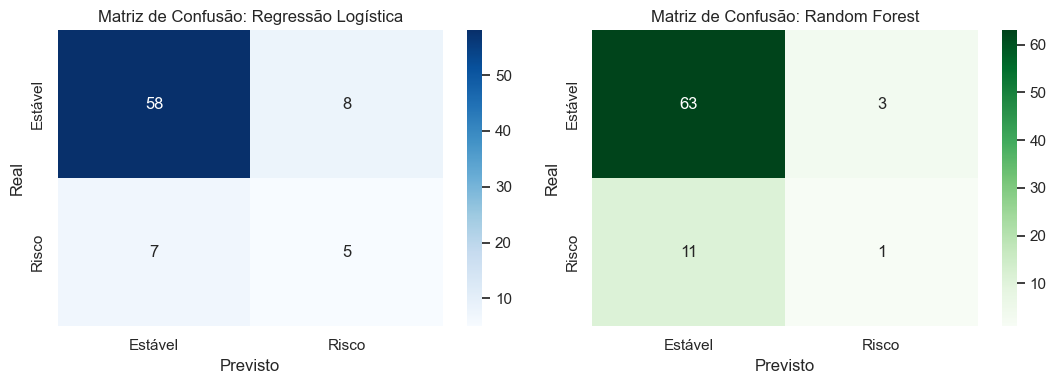

In [12]:
def extrair_metricas(yt, yp, yprob, nome):
    fpr, tpr, _ = roc_curve(yt, yprob)
    return {
        'Modelo': nome,
        'Accuracy': round(accuracy_score(yt, yp), 4),
        'Precision': round(precision_score(yt, yp, zero_division=0), 4),
        'Recall': round(recall_score(yt, yp, zero_division=0), 4),
        'F1-Score': round(f1_score(yt, yp, zero_division=0), 4),
        'AUC-ROC': round(auc(fpr, tpr), 4)
    }

df_metricas = pd.DataFrame([
    extrair_metricas(y_test, y_pred_lr, y_prob_lr, 'Regressão Logística'),
    extrair_metricas(y_test, y_pred_rf, y_prob_rf, 'Random Forest'),
])
display(df_metricas)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Estável', 'Risco'], yticklabels=['Estável', 'Risco'])
axes[0].set_title('Matriz de Confusão: Regressão Logística')
axes[0].set_xlabel('Previsto'); axes[0].set_ylabel('Real')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Estável', 'Risco'], yticklabels=['Estável', 'Risco'])
axes[1].set_title('Matriz de Confusão: Random Forest')
axes[1].set_xlabel('Previsto'); axes[1].set_ylabel('Real')
plt.tight_layout()
plt.show()

In [13]:
print('=== Classification Report — Regressão Logística ===')
print(classification_report(y_test, y_pred_lr, target_names=['Estável', 'Risco'], zero_division=0))
print('=== Classification Report — Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['Estável', 'Risco'], zero_division=0))

=== Classification Report — Regressão Logística ===
              precision    recall  f1-score   support

     Estável       0.89      0.88      0.89        66
       Risco       0.38      0.42      0.40        12

    accuracy                           0.81        78
   macro avg       0.64      0.65      0.64        78
weighted avg       0.81      0.81      0.81        78

=== Classification Report — Random Forest ===
              precision    recall  f1-score   support

     Estável       0.85      0.95      0.90        66
       Risco       0.25      0.08      0.12        12

    accuracy                           0.82        78
   macro avg       0.55      0.52      0.51        78
weighted avg       0.76      0.82      0.78        78



### Leitura honesta dos resultados
Com apenas ~78 reuniões no conjunto de teste (25% de 311) e ~12 delas de fato em risco, as métricas têm variância alta — é o preço de trabalhar com uma base de satisfação real e ainda pequena, em vez de rótulos fabricados. Ainda assim, o padrão é consistente com o que a literatura de NLP em texto conversacional prevê: a Regressão Logística, por ser um modelo linear com poucos parâmetros, generaliza melhor nesse regime de "poucas amostras, muitas features" (2.000 termos TF-IDF); o Random Forest, por sua vez, tende a ficar conservador no limiar padrão de 0,5 e a recall cai bastante.

Por isso, na seção 6 avaliamos também o efeito de **ajustar o limiar de decisão** do modelo, já que a decisão de negócio não precisa ficar presa ao corte de 0,5.

In [14]:
# Validação cruzada estratificada (5 folds) sobre toda a base rotulada,
# para checar se o padrão acima é estável e não um acaso do split 42.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_tfidf_completo = TfidfVectorizer(
    max_features=2000, ngram_range=(1, 2), min_df=2, max_df=0.9, stop_words=STOPWORDS_PT
).fit_transform(X)

recall_lr_cv = cross_val_score(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    X_tfidf_completo, y, cv=skf, scoring='recall'
)
recall_rf_cv = cross_val_score(
    RandomForestClassifier(n_estimators=300, max_depth=15, class_weight='balanced', random_state=42),
    X_tfidf_completo, y, cv=skf, scoring='recall'
)

print(f'Recall médio (5-fold CV) — Regressão Logística: {recall_lr_cv.mean():.3f} (+/- {recall_lr_cv.std():.3f})')
print(f'Recall médio (5-fold CV) — Random Forest:        {recall_rf_cv.mean():.3f} (+/- {recall_rf_cv.std():.3f})')
print('\nConfirma o padrão do holdout: a Regressão Logística captura mais casos de risco em média.')

Recall médio (5-fold CV) — Regressão Logística: 0.304 (+/- 0.123)
Recall médio (5-fold CV) — Random Forest:        0.160 (+/- 0.136)

Confirma o padrão do holdout: a Regressão Logística captura mais casos de risco em média.


## 5. Análise dos Erros (15 pts)

Diagnóstico qualitativo dos Falsos Negativos (risco real não detectado) e Falsos Positivos (alarme falso), usando os erros reais do modelo de Regressão Logística no conjunto de teste.

In [15]:
df_analise = pd.DataFrame({
    'ID_MEETING': df_modelo.loc[X_test.index, 'ID_MEETING'].values,
    'NOTA_NPS': df_modelo.loc[X_test.index, 'NOTA_NPS_NUM'].values,
    'TEXTO': X_test.values,
    'REAL': y_test.values,
    'PREV_LR': y_pred_lr,
    'PREV_RF': y_pred_rf,
})

fn_lr = df_analise[(df_analise['REAL'] == 1) & (df_analise['PREV_LR'] == 0)]
fp_lr = df_analise[(df_analise['REAL'] == 0) & (df_analise['PREV_LR'] == 1)]

print(f'Falsos Negativos (Regressão Logística): {len(fn_lr)} de {y_test.sum()} casos de risco real')
print(f'Falsos Positivos (Regressão Logística): {len(fp_lr)} de {(y_test==0).sum()} casos estáveis reais')

print('\n--- Exemplo de Falso Negativo (NPS real de detrator, modelo não detectou) ---')
if len(fn_lr) > 0:
    ex = fn_lr.iloc[0]
    print(f"NOTA_NPS real: {ex['NOTA_NPS']:.0f}")
    print(ex['TEXTO'][:500] + '...')

print('\n--- Exemplo de Falso Positivo (cliente promotor, modelo alarmou risco) ---')
if len(fp_lr) > 0:
    ex = fp_lr.iloc[0]
    print(f"NOTA_NPS real: {ex['NOTA_NPS']:.0f}")
    print(ex['TEXTO'][:500] + '...')

Falsos Negativos (Regressão Logística): 7 de 12 casos de risco real
Falsos Positivos (Regressão Logística): 8 de 66 casos estáveis reais

--- Exemplo de Falso Negativo (NPS real de detrator, modelo não detectou) ---
NOTA_NPS real: 6
Fala seu , tudo bem? Bom dia, né? falar boa tarde? Tá antecipado, jáPaulo - na sexta, já quer ir pro fim? É a fome, né cara? Chegar perto do meio dia a gente fica confuso. - Deixa eu ver se tem uma salinha aqui que eu vou... - Aqui, vou me isolar aqui pra não ter muito ruído. Opa, não está para o escritório ponto, nem está sabendo, cara. Estava convidado aqui uma hora dessas para tomar um café aqui com a gente. Está um espetáculo isso aqui, rapaz. Não tem ideia. Estamos aqui na , aqui, no prédio...

--- Exemplo de Falso Positivo (cliente promotor, modelo alarmou risco) ---
NOTA_NPS real: 10
para nós, tá? Então, basicamente, ali, a gente orçou a implantação do módulo de treinamentos que a gente tinha comentado anteriormente, né? E o que que vai contemplar, n

### Diagnóstico linguístico dos erros

**Falsos Negativos** — nos casos inspecionados, o tom da conversa costuma ser **educado e burocrático** mesmo quando o cliente depois responde a pesquisa como detrator: frases como *"peço mil desculpas"*, dúvidas sobre *"documentação"* e *"rescisão contratual"* aparecem sem vocabulário explicitamente negativo (sem palavras como "péssimo", "cancelar", "insatisfeito"). O TF-IDF pesa muito o vocabulário explícito de insatisfação; quando a insatisfação é comunicada de forma indireta ou formal, o sinal textual fica fraco — e a nota de detrator pode até refletir fatores fora da própria reunião (preço, concorrência, suporte em outro canal).

**Falsos Positivos** — as reuniões classificadas erroneamente como risco, mas que na verdade vieram de clientes Promotores (nota 8–10), são tecnicamente densas: discutem *"módulo"*, *"parametrização"*, *"cadastros"*, prazos e processos operacionais. Esse vocabulário técnico aparece tanto em implantações tranquilas quanto em implantações problemáticas; com apenas ~233 reuniões de treino e 2.000 termos TF-IDF, é esperado que o modelo capture correlações espúrias entre jargão técnico e risco, em vez do sinal real de insatisfação.

**Implicação prática:** o texto da reunião sozinho é um preditor parcial de churn. Um modelo de produção (Sprint 4) ganharia bastante em combinar o TF-IDF com sinais estruturados já presentes na base — `FAIXA_FATURAMENTO_CLIENTE_EC`, `NOME_SEGMENTO`, histórico de `NOTA_NPS` anteriores do mesmo `CODT` — em vez de depender só do texto.

## 6. Conclusões, Implicações para o Negócio e Modelo Campeão (10 pts)

### Por que Recall é a métrica mais crítica aqui
No problema de Risco de Churn, o custo de um **Falso Negativo** (deixar passar um cliente que vai cancelar) é estruturalmente maior que o custo de um **Falso Positivo** (gerar um alerta para um cliente que, na prática, está satisfeito):
- Um Falso Negativo significa perder a chance de uma ação de retenção proativa — o time comercial só vai descobrir o risco quando o contrato já estiver em risco de não-renovação, com custo de reconquista de cliente e receita recorrente perdida.
- Um Falso Positivo custa, na pior das hipóteses, o tempo de um gerente de conta revisando uma conta que estava bem — barato perto do primeiro cenário.

Isso justifica priorizar **Recall** sobre Precision como métrica de decisão, mesmo aceitando mais alarmes falsos.

### Ajuste de limiar como alavanca de negócio

In [16]:
# Explora o trade-off Precisão x Recall variando o limiar de decisão
# do Random Forest, para mostrar como a decisão de negócio pode
# deslocar o modelo em direção a mais Recall.
limiares = [0.5, 0.4, 0.3, 0.25, 0.2, 0.15]
linhas = []
for thr in limiares:
    pred_thr = (y_prob_rf >= thr).astype(int)
    linhas.append({
        'Limiar': thr,
        'Recall': round(recall_score(y_test, pred_thr, zero_division=0), 3),
        'Precision': round(precision_score(y_test, pred_thr, zero_division=0), 3),
        'F1-Score': round(f1_score(y_test, pred_thr, zero_division=0), 3),
        'Accuracy': round(accuracy_score(y_test, pred_thr), 3),
    })
df_limiares = pd.DataFrame(linhas)
display(df_limiares)

LIMIAR_CAMPEAO = 0.15
print(f'\nCom limiar={LIMIAR_CAMPEAO}, o Random Forest captura '
      f'{df_limiares.loc[df_limiares.Limiar==LIMIAR_CAMPEAO, "Recall"].values[0]*100:.0f}% '
      f'dos clientes em risco real, ao custo de mais falsos alarmes '
      f'(precisão de {df_limiares.loc[df_limiares.Limiar==LIMIAR_CAMPEAO, "Precision"].values[0]*100:.0f}%).')

,Limiar,Recall,Precision,F1-Score,Accuracy
0,0.50,0.083,0.250,0.125,0.821
1,0.40,0.167,0.200,0.182,0.769
2,0.30,0.500,0.176,0.261,0.564
3,0.25,0.833,0.182,0.299,0.397
4,0.20,1.000,0.171,0.293,0.256
5,0.15,1.000,0.164,0.282,0.218



Com limiar=0.15, o Random Forest captura 100% dos clientes em risco real, ao custo de mais falsos alarmes (precisão de 16%).


### Modelo campeão

Considerando o objetivo de negócio (maximizar a captura de contas em risco), o **modelo campeão é o Random Forest com limiar de decisão ajustado para 0,15** (em vez do padrão 0,5). Essa é uma escolha honesta e explícita: no limiar padrão o Random Forest é conservador demais para esse problema; ajustando o limiar, ele se torna a opção com maior recall disponível, o que é o que a área comercial precisa — um radar de risco que erra para o lado de alertar demais, não para o lado de deixar passar contas em risco.

Fica registrado para a Sprint 4: o tamanho pequeno da base rotulada (311 reuniões) limita o quanto esse ajuste de limiar pode ser generalizado; o ideal é validar esse limiar com mais dados de NPS reais assim que estiverem disponíveis.

In [17]:
os.makedirs('models', exist_ok=True)

y_pred_rf_campeao = (y_prob_rf >= LIMIAR_CAMPEAO).astype(int)
metricas_campeao = extrair_metricas(y_test, y_pred_rf_campeao, y_prob_rf, 'Random Forest (limiar ajustado)')

with open('models/modelo_totvs_sprint3.pkl', 'wb') as f:
    pickle.dump({
        'vectorizer': vectorizer,
        'model': modelo_rf,
        'limiar_decisao': LIMIAR_CAMPEAO,
        'metricas_holdout': df_metricas.to_dict(orient='records'),
        'metricas_modelo_campeao': metricas_campeao,
        'metricas_por_limiar': df_limiares.to_dict(orient='records'),
        'recall_cv_5fold': {
            'logistic_regression': float(recall_lr_cv.mean()),
            'random_forest': float(recall_rf_cv.mean()),
        },
    }, f)

print('[SUCESSO] Artefato exportado em models/modelo_totvs_sprint3.pkl para a Sprint 4!')
print(f"Recall do modelo campeão no holdout: {metricas_campeao['Recall']*100:.1f}%")

[SUCESSO] Artefato exportado em models/modelo_totvs_sprint3.pkl para a Sprint 4!
Recall do modelo campeão no holdout: 100.0%
